In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Library berhasil dimuat!")

Library berhasil dimuat!


In [2]:
df = pd.read_csv('MBG Historis Latest 2.csv')

df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal')
df.set_index('Tanggal', inplace=True)

kolom_gizi = df.columns.tolist()
df.head()

,Karbohidrat Besar,Protein Besar,Lemak Besar,Serat Besar,Energi Besar,Karbohidrat Kecil,Protein Kecil,Lemak Kecil,Serat Kecil,Energi Kecil
Tanggal,,,,,,,,,,
2025-12-01,75.0,16.0,19.0,0.0,545.0,55.0,15.0,19.0,0.0,455.0
2025-12-02,85.0,17.0,16.0,0.0,595.0,85.0,17.0,16.0,0.0,510.0
2025-12-03,85.0,15.0,22.0,0.0,595.0,65.0,12.0,18.0,0.0,468.0
2025-12-04,105.0,17.0,21.0,0.0,680.0,86.0,15.0,21.0,0.0,585.0
2025-12-05,60.0,19.0,26.0,0.0,554.0,40.0,16.0,26.0,0.0,454.0


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[kolom_gizi])

def create_sequences_seluruhnya(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 7
X, y = create_sequences_seluruhnya(data_scaled, time_steps)

print("Bentuk keseluruhan X (Input) :", X.shape)
print("Bentuk keseluruhan y (Target):", y.shape)

Bentuk keseluruhan X (Input) : (80, 7, 10)
Bentuk keseluruhan y (Target): (80, 10)


In [4]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Bentuk X_train :", X_train.shape)
print("Bentuk y_train :", y_train.shape)
print("Bentuk X_test  :", X_test.shape)
print("Bentuk y_test  :", y_test.shape)

Bentuk X_train : (64, 7, 10)
Bentuk y_train : (64, 10)
Bentuk X_test  : (16, 7, 10)
Bentuk y_test  : (16, 10)


In [5]:
model = Sequential()

model.add(LSTM(units=32, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=10))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 32)          │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,154 (55.29 KB)

 Trainable params: 14,154 (55.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.3215 - val_loss: 0.1725
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2019 - val_loss: 0.0909
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1320 - val_loss: 0.0468
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0900 - val_loss: 0.0330
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0778 - val_loss: 0.0364
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0677 - val_loss: 0.0338
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0666 - val_loss: 0.0310
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0650 - val_loss: 0.0286
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0627 - val_loss: 0.0285
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0601 - val_loss: 0.0294
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0637 - val_loss: 0.0315
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0590 - val_lo

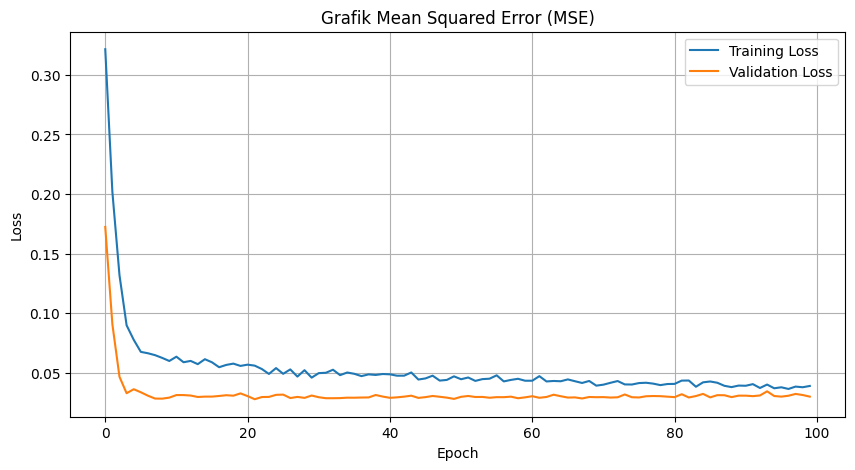

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Mean Squared Error (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
prediksi_scaled = model.predict(X_test)

prediksi_asli = scaler.inverse_transform(prediksi_scaled)
nilai_aktual_asli = scaler.inverse_transform(y_test)

hasil_df = pd.DataFrame({
    'Komponen Gizi': kolom_gizi,
    'Nilai Aktual': np.round(nilai_aktual_asli[0], 2),
    'Hasil Prediksi': np.round(prediksi_asli[0], 2)
})

print("\nKomparasi Prediksi vs Aktual (Untuk Hari Pertama Data Test):")
hasil_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step

Komparasi Prediksi vs Aktual (Untuk Hari Pertama Data Test):


,Komponen Gizi,Nilai Aktual,Hasil Prediksi
0,Karbohidrat Besar,105.0,88.769997
1,Protein Besar,25.0,24.139999
2,Lemak Besar,25.0,24.080000
3,Serat Besar,6.0,4.760000
4,Energi Besar,740.0,684.710022
5,Karbohidrat Kecil,47.0,53.259998
6,Protein Kecil,9.0,14.780000
7,Lemak Kecil,12.0,16.379999
8,Serat Kecil,3.0,2.480000
9,Energi Kecil,335.0,449.170013


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

rmse_list = []
mae_list = []
mape_list = []

for i in range(len(kolom_gizi)):
    aktual_per_kolom = nilai_aktual_asli[:, i]
    prediksi_per_kolom = prediksi_asli[:, i]

    rmse = np.sqrt(mean_squared_error(aktual_per_kolom, prediksi_per_kolom))
    rmse_list.append(rmse)

    mae = mean_absolute_error(aktual_per_kolom, prediksi_per_kolom)
    mae_list.append(mae)

    mape = mean_absolute_percentage_error(aktual_per_kolom, prediksi_per_kolom) * 100
    mape_list.append(mape)

evaluasi_df = pd.DataFrame({
    'Komponen Gizi': kolom_gizi,
    'RMSE': np.round(rmse_list, 2),
    'MAE': np.round(mae_list, 2),
    'MAPE (%)': np.round(mape_list, 2)
})

# Hitung Rata-rata keseluruhan
print("HASIL EVALUASI MODEL KESELURUHAN")
print(f"Rata-rata RMSE Keseluruhan : {np.mean(rmse_list):.2f}")
print(f"Rata-rata MAE Keseluruhan  : {np.mean(mae_list):.2f}")
print(f"Rata-rata MAPE Keseluruhan : {np.mean(mape_list):.2f}%\n")

print("=== RINCIAN EVALUASI PER KOLOM ===")
evaluasi_df

HASIL EVALUASI MODEL KESELURUHAN
Rata-rata RMSE Keseluruhan : 21.85
Rata-rata MAE Keseluruhan  : 19.58
Rata-rata MAPE Keseluruhan : 33.44%

=== RINCIAN EVALUASI PER KOLOM ===


,Komponen Gizi,RMSE,MAE,MAPE (%)
0,Karbohidrat Besar,24.10,21.41,34.88
1,Protein Besar,3.89,3.30,15.72
2,Lemak Besar,5.13,3.55,27.35
3,Serat Besar,2.11,1.69,74.47
4,Energi Besar,107.56,99.98,15.53
5,Karbohidrat Kecil,6.59,5.68,12.12
6,Protein Kecil,5.13,4.48,44.58
7,Lemak Kecil,4.64,4.08,41.09
8,Serat Kecil,1.23,0.98,54.26
9,Energi Kecil,58.16,50.60,14.40


In [10]:
import torch
import torch.nn as nn
import joblib
import numpy as np

class LSTMModelPT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMModelPT, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out[:, -1, :])
        out = self.fc(out)
        return out

# Inisialisasi model PyTorch
pt_model = LSTMModelPT(input_dim=X_train.shape[2], hidden_dim=32, output_dim=10)

# 2. Fungsi untuk menyalin Bobot dari Keras ke PyTorch
def transfer_weights(keras_model, pt_model):
    kw = keras_model.get_weights()
    def to_pt_lstm(w_ih, w_hh, b):
        u = w_hh.shape[1] // 4
        idx = np.concatenate([np.arange(0,u), np.arange(2*u,3*u), np.arange(u,2*u), np.arange(3*u,4*u)])
        return torch.FloatTensor(w_ih.T[idx, :]), torch.FloatTensor(w_hh.T[idx, :]), torch.FloatTensor(b[idx])

    # Layer 1
    w1, h1, b1 = to_pt_lstm(kw[0], kw[1], kw[2])
    pt_model.lstm1.weight_ih_l0.data, pt_model.lstm1.weight_hh_l0.data, pt_model.lstm1.bias_ih_l0.data = w1, h1, b1
    pt_model.lstm1.bias_hh_l0.data.fill_(0)
    # Layer 2
    w2, h2, b2 = to_pt_lstm(kw[3], kw[4], kw[5])
    pt_model.lstm2.weight_ih_l0.data, pt_model.lstm2.weight_hh_l0.data, pt_model.lstm2.bias_ih_l0.data = w2, h2, b2
    pt_model.lstm2.bias_hh_l0.data.fill_(0)
    # Dense Layer
    pt_model.fc.weight.data = torch.FloatTensor(kw[6].T)
    pt_model.fc.bias.data = torch.FloatTensor(kw[7])

transfer_weights(model, pt_model)

# 3. Simpan File dengan ekstensi .pt
nama_file_model = 'model_lstm_nutrisi.pt'
nama_file_scaler = 'scaler_nutrisi.save'

torch.save(pt_model.state_dict(), nama_file_model)
joblib.dump(scaler, nama_file_scaler)

print(f"✓ Model PyTorch disimpan: {nama_file_model}")
print(f"✓ Scaler disimpan: {nama_file_scaler}")

✓ Model PyTorch disimpan: model_lstm_nutrisi.pt
✓ Scaler disimpan: scaler_nutrisi.save
